# 2. 데이터 전처리 및 EDA

1번 노트북에서 생성한 `master_DDQN.csv`를 불러와 결측값과 이상치를 확인하고 파생변수를 만든다. 변수는 데이터 생성 시점에 따라 구분한다.

- **Set A**: 스케줄링 이전에 알 수 있는 Block 고유 특성 — 최종 Cycle 예측용
- **Set B/C**: DDQN이 선택한 Position·Initial 결과를 붙인 변수 — 탐색적 진단용

> 이 노트북은 Position 결과를 Block의 사전 속성으로 간주하지 않는다. Set B/C는 사후 정보를 추가했을 때 통계적 성능이 어떻게 변하는지 확인하기 위해 유지한다.


## 2.1 데이터 전처리 및 변수 구성

### 2.1.1 Master Table 불러오기

1번 노트북에서 저장한 DDQN 기준 Master Table을 불러온다. 원본 보존을 위해 `analysis`를 별도로 복사하여 사용한다.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = Path('data') / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(PROCESSED_DIR / 'master_DDQN.csv')
analysis = master.copy()

master.info()
master.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   block_index                  872 non-null    int64  
 1   block_ship_no                872 non-null    object 
 2   block_no                     872 non-null    int64  
 3   result_block_sequence_no     872 non-null    int64  
 4   position_id                  872 non-null    object 
 5   position_index               872 non-null    int64  
 6   position_description         872 non-null    object 
 7   block_type                   872 non-null    object 
 8   block_length                 872 non-null    float64
 9   block_width                  872 non-null    float64
 10  block output                 872 non-null    float64
 11  block_weight                 872 non-null    float64
 12  block_is_combined            2 non-null      float64
 13  block_combined_block

,block_index,block_ship_no,block_no,result_block_sequence_no,position_id,position_index,position_description,block_type,block_length,block_width,...,position_designated_block,position_block_type,position_attribute,position_column1,initial_ship_no,initial_vessel_type,initial_block_no,initial_earliest_start,initial_expected_completion,block_processing_cycle
0,757,H1088,284,757,PPT0811A,94,No.8 South-21,flat,20.000,18.400,...,NaN,flat,general,NaN,NaN,NaN,NaN,NaN,NaN,72
1,758,H1088,294,758,PPT1057A,78,No.10 North-14,flat,20.000,18.400,...,NaN,NaN,general,NaN,NaN,NaN,NaN,NaN,NaN,71
2,823,H1088,836,823,PPT0809A,92,No.8 South-17,flat,6.450,21.691,...,NaN,NaN,general,NaN,NaN,NaN,NaN,NaN,NaN,53
3,822,H1088,826,822,BQM4810A,10,48 South-10,flat,20.852,21.691,...,NaN,NaN,general,NaN,H1098,17.7,153.0,2017-10-20,2017-11-08,53
4,819,H1088,101,819,BQM4503A,22,45 South-3,flat,30.660,9.400,...,NaN,flat,general,NaN,H1103,31.6,183.0,2017-10-26,2017-11-16,61


### 2.1.2 데이터 품질 확인

행 수, 중복, 종속변수 결측 여부와 컬럼별 결측값을 먼저 확인한다.

In [2]:
# 기본 무결성 확인(조인과정에서 block값이 늘어나진 않았는지, 종속변수의 결측은 없는지)
print('block_index 중복:', analysis['block_index'].duplicated().sum())
print('종속변수 결측:', analysis['block_processing_cycle'].isna().sum())

# 결측치가 있는 컬럼만 확인
missing = analysis.isna().sum()
missing[missing > 0].sort_index()

block_index 중복: 0
종속변수 결측: 0


block_combined_block           870
block_is_combined              870
initial_block_no               690
initial_earliest_start         690
initial_expected_completion    690
initial_ship_no                690
initial_vessel_type            690
position_block_type            391
position_column1               846
position_designated_block      872
position_height_limit          690
dtype: int64

### 2.1.3 결측값 해석 및 처리

결측값을 일괄적으로 평균이나 최빈값으로 대체하지 않는다. 각 컬럼의 의미와 분포를 확인한 뒤, 정보량이 부족한 변수는 제외하고 구조적 결측은 별도 범주나 상태 변수로 변환한다.

#### 2.1.3.1 `block_is_combined`와 `block_combined_block`

두 컬럼은 전체 872개 Block 중 2개 행에만 값이 있다. 유효 표본이 지나치게 적어 일반적인 관계를 학습하기 어려우므로 모델링 변수에서 제외한다.

In [3]:
analysis[(analysis['block_is_combined'].notna())&(analysis['block_combined_block'].notna())]

,block_index,block_ship_no,block_no,result_block_sequence_no,position_id,position_index,position_description,block_type,block_length,block_width,...,position_designated_block,position_block_type,position_attribute,position_column1,initial_ship_no,initial_vessel_type,initial_block_no,initial_earliest_start,initial_expected_completion,block_processing_cycle
785,34,H1087,293,34,BQM4803A,3,48 South-3,flat,22.500,18.320,...,NaN,NaN,general,NaN,H1094,17.7,154.0,2017-10-25,2017-11-12,39
870,9,H1087,835,9,PPT1012A,70,No.10 South-23,flat,7.416,16.884,...,NaN,flat,general,NaN,NaN,NaN,NaN,NaN,NaN,27


#### 2.1.3.2 `position_designated_block`와 `position_column1`

- `position_designated_block`: DDQN Master Table에서 전부 결측이므로 정보량이 없다.
- `position_column1`: 대부분 결측이며 명확한 변수 정의를 확인하기 어렵다.

두 컬럼 모두 현재 모델링 변수에서 제외한다.

In [4]:

analysis[['position_designated_block','position_column1']].notna().sum()

position_designated_block     0
position_column1             26
dtype: int64

#### 2.1.3.3 `position_height_limit`

`position_height_limit`은 특정 Primary Area에서만 값이 존재하는 구조적 결측이다. `position_primary_area`와 정보가 중복될 가능성이 크므로 현재 모델링 변수에서는 제외한다.

In [5]:
#먼저 'height limit (M)'의 dtype 확인
analysis['position_height_limit'].unique()

array([nan, '9', '9M'], dtype=object)

In [6]:
# position_height_limit에 문자 'M'이 포함된 값을 숫자로 변환하기 위해 'M' 제거 (예: '9M' → '9')
analysis['position_height_limit'] = (analysis['position_height_limit'].astype(str).str.replace('M', '', regex=False))

# 정리된 값을 숫자형으로 변환, 숫자로 변환할 수 없는 값은 NaN으로 처리
analysis['position_height_limit'] = pd.to_numeric(analysis['position_height_limit'],errors='coerce')

In [7]:
analysis['position_height_limit'].unique()

array([nan,  9.])

In [8]:
# 'position_primary_area'는 범주형 변수이므로 corr() 대신 groupby()를 사용
# 결측값도 많고 'position primary area'에 의해 100% 결정되므로 변수에서 제외할 필요가 있음.
analysis.groupby(['position_primary_area'],dropna=False)['position_height_limit'].agg(total='size',non_null='count')

,total,non_null
position_primary_area,,
block assembly group,197,0
curved surface,182,182
platform 1,493,0


#### 2.1.3.4 `position_block_type`

Position의 Block Type 값이 없는 경우에는 특정 Block Type 제한이 없는 Position으로 해석하고 `unrestricted`로 변환한다.

In [9]:
#먼저 'position_block_type'의 dtype 확인
analysis['position_block_type'].unique()

array(['flat', nan, 'curved'], dtype=object)

In [10]:
pd.crosstab(analysis['position_block_type'], analysis['block_type'], margins=True, dropna=False)
# 'curved' 제한 Position에는 curved Block만, 'flat' 제한 Position에는 flat Block만 배치됨
#  NaN에는 curved와 flat Block이 모두 배치되어 제한 없는 Position으로 해석 가능

block_type,curved,flat,All
position_block_type,,,
curved,110,0,110.0
flat,0,371,371.0
NaN,23,368,NaN
All,133,739,872.0


In [11]:
# position_block_type의 결측치는 특정 Block Type 제한이 없는 Position으로 해석하여 'unrestricted' 범주로 변환
analysis['position_block_type'] = (analysis['position_block_type'].fillna('unrestricted'))


#### 2.1.3.5 Initial 상태 정보

- `initial_ship_no`, `initial_block_no`, `initial_vessel_type`  
  초기 점유 Block의 식별·분류 정보이므로 최종 Cycle 예측변수에서 제외한다.

- `initial_earliest_start`, `initial_expected_completion`  
  스케줄링의 가용성 조건으로는 의미가 있지만 Block Cycle의 사전 예측변수는 아니다. 4번 Scheduling Result 비교와 향후 Scheduling Engine의 입력조건으로 분리한다.

- `initially_occupied`  
  Initial Table에 Position 기록이 있는지를 표현하는 탐색용 플래그다. Set C의 사후 진단에만 사용한다.


### 2.1.4 파생변수 생성

날짜와 물리량을 이용해 다음 변수를 만든다. Block 파생변수와 Result 결합 후에만 알 수 있는 Position 파생변수를 구분한다.

| 구분 | 파생변수 | 의미 | 사용 |
|---|---|---|---|
| Block | `season` | on-position date가 속한 계절 | Set A |
| Block | `block_start_window` | latest start와 earliest start 사이의 일수 | Set A |
| Block | `block_area` | Block 길이 × 폭 | Set A |
| Position | `position_area` | 선택 Position 길이 × 폭 | Set B/C 탐색 |
| Block–Position | `area_margin_ratio` | 선택 Position 면적 중 Block 배치 후 남는 비율 | Set B/C 탐색 |
| Block–Position | `lifting_load_ratio` | 선택 Position 인양 능력 대비 Block 중량 | Set B/C 탐색 |
| Initial | `initially_occupied` | Initial Table에 기록된 Position 여부 | Set C 탐색 |


In [12]:
# ============================================================
# 1. 계절 변수 생성
# ============================================================

# on-position date를 datetime 형식으로 변환한 뒤,
# 해당 월을 기준으로 계절 범주 생성
analysis['block_on_position_date'] = pd.to_datetime(
    analysis['block_on_position_date']
)

analysis['season'] = (
    analysis['block_on_position_date']
    .dt.month
    .map({
        12: 'winter', 1: 'winter', 2: 'winter',
        3: 'spring', 4: 'spring', 5: 'spring',
        6: 'summer', 7: 'summer', 8: 'summer',
        9: 'autumn', 10: 'autumn', 11: 'autumn'
    })
)


# ============================================================
# 2. Block 작업 시작 가능 기간 생성
# ============================================================

# earliest / latest start time을 datetime 형식으로 변환한 뒤,
# 두 시점의 차이를 일(day) 단위로 계산
analysis['block_earliest_start'] = pd.to_datetime(
    analysis['block_earliest_start']
)

analysis['block_latest_start'] = pd.to_datetime(
    analysis['block_latest_start']
)

analysis['block_start_window'] = (
    analysis['block_latest_start']
    - analysis['block_earliest_start']
).dt.days


# ============================================================
# 3. 공간 여유 비율 생성
# ============================================================

# Block의 가로 × 세로를 이용해 Block 면적 계산
analysis['block_area'] = (
    analysis['block_length']
    * analysis['block_width']
)

# Position의 size 문자열을 길이와 폭으로 분리
# 예: '20*15' → position_length=20, position_width=15
analysis[[
    'position_length',
    'position_width'
]] = (
    analysis['position_size']
    .str.split('*', expand=True)
    .astype(float)
)

# Position의 길이 × 폭을 이용해 Position 면적 계산
analysis['position_area'] = (
    analysis['position_length']
    * analysis['position_width']
)

# Position 면적 대비 Block 배치 후 남는 면적 비율 계산
# → 값이 클수록 상대적인 공간 여유가 큼
analysis['area_margin_ratio'] = (
    analysis['position_area']
    - analysis['block_area']
) / analysis['position_area']


# ============================================================
# 4. 인양능력 사용 비율 생성
# ============================================================

# Position 인양능력 대비 Block 무게의 비율 계산
# → 값이 1에 가까울수록 인양능력을 많이 사용하는 Block
analysis['lifting_load_ratio'] = (
    analysis['block_weight']
    / analysis['position_lifting_capacity']
)


# ============================================================
# 5. 초기 점유 상태 변수 생성
# ============================================================

# Initial Table에 해당 Position의 기록이 존재하는지 여부를 이용해
# 스케줄링 시작 시점의 초기 점유 상태 생성
# 1: Initial Table에 기록된 Position
# 0: Initial Table에 기록되지 않은 Position
analysis['initially_occupied'] = (
    analysis['initial_ship_no']
    .notna()
    .astype(int)
)


# ============================================================
# 6. 생성된 파생변수 확인
# ============================================================

analysis[[
    'season',
    'block_start_window',
    'area_margin_ratio',
    'lifting_load_ratio',
    'initially_occupied'
]].head()

,season,block_start_window,area_margin_ratio,lifting_load_ratio,initially_occupied
0,spring,126,0.163636,0.602906,0
1,spring,125,0.080000,0.753633,0
2,spring,79,0.682030,0.418042,0
3,spring,79,0.020994,1.000000,1
4,spring,85,0.584121,1.000000,1


### 2.1.5 이상치 확인

IQR 기준으로 수치형 변수의 이상치 후보를 확인한다. 이상치는 오류 데이터가 아니라 크거나 긴 작업 특성을 가진 Block일 수 있으므로 이 단계에서는 제거하지 않는다.

In [13]:
# 이상치 검토 대상이 되는 주요 수치형 변수 지정
outlier_cols = [
    'block_length',
    'block_width',
    'block_weight',
    'block_start_window',
    'block_area',
    'area_margin_ratio',
    'lifting_load_ratio',
    'block_processing_cycle'
]


# 각 변수의 IQR 기준 이상치 정보를 저장할 리스트 생성
outlier_summary = []


# 변수별로 IQR 방식의 이상치 범위 및 이상치 개수 계산
for col in outlier_cols:

    # 1사분위수(Q1)와 3사분위수(Q3) 계산
    q1 = analysis[col].quantile(0.25)
    q3 = analysis[col].quantile(0.75)

    # IQR = Q3 - Q1
    iqr = q3 - q1

    # 일반적인 IQR 기준에 따라 이상치 경계값 설정
    # 하한: Q1 - 1.5 × IQR
    # 상한: Q3 + 1.5 × IQR
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 하한보다 작거나 상한보다 큰 값의 개수 계산
    count = (
        (analysis[col] < lower)
        | (analysis[col] > upper)
    ).sum()

    # 변수별 이상치 검토 결과 저장
    outlier_summary.append({
        'variable': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': count
    })


# 변수별 이상치 경계값과 이상치 개수를 DataFrame으로 정리
pd.DataFrame(outlier_summary).round(2)

,variable,lower_bound,upper_bound,outlier_count
0,block_length,4.78,27.80,32
1,block_width,7.49,25.50,28
2,block_weight,32.31,278.91,0
3,block_start_window,18.88,87.88,8
4,block_area,-4.44,501.22,10
5,area_margin_ratio,-0.16,1.05,0
6,lifting_load_ratio,0.05,1.02,0
7,block_processing_cycle,0.50,52.50,13


#### 2.1.5.1 이상치 확인 소결론

IQR 기준으로 일부 변수에서 이상치 후보가 확인되었으나, Boxplot상 대부분 연속적인 분포의 꼬리에 위치하며 명백한 입력 오류로 판단할 만한 값은 확인되지 않았다.

특히 Block의 크기와 Processing Cycle은 작업 대상의 특성에 따라 실제 편차가 발생할 수 있으므로, 현 단계에서는 이상치를 제거하지 않고 유지한다. 이후 모델링 과정에서 특정 관측치가 예측 오차에 과도한 영향을 미치는 경우 해당 데이터를 개별적으로 재검토한다. 아래 그래프는 이 결론에 대한 내용이다.

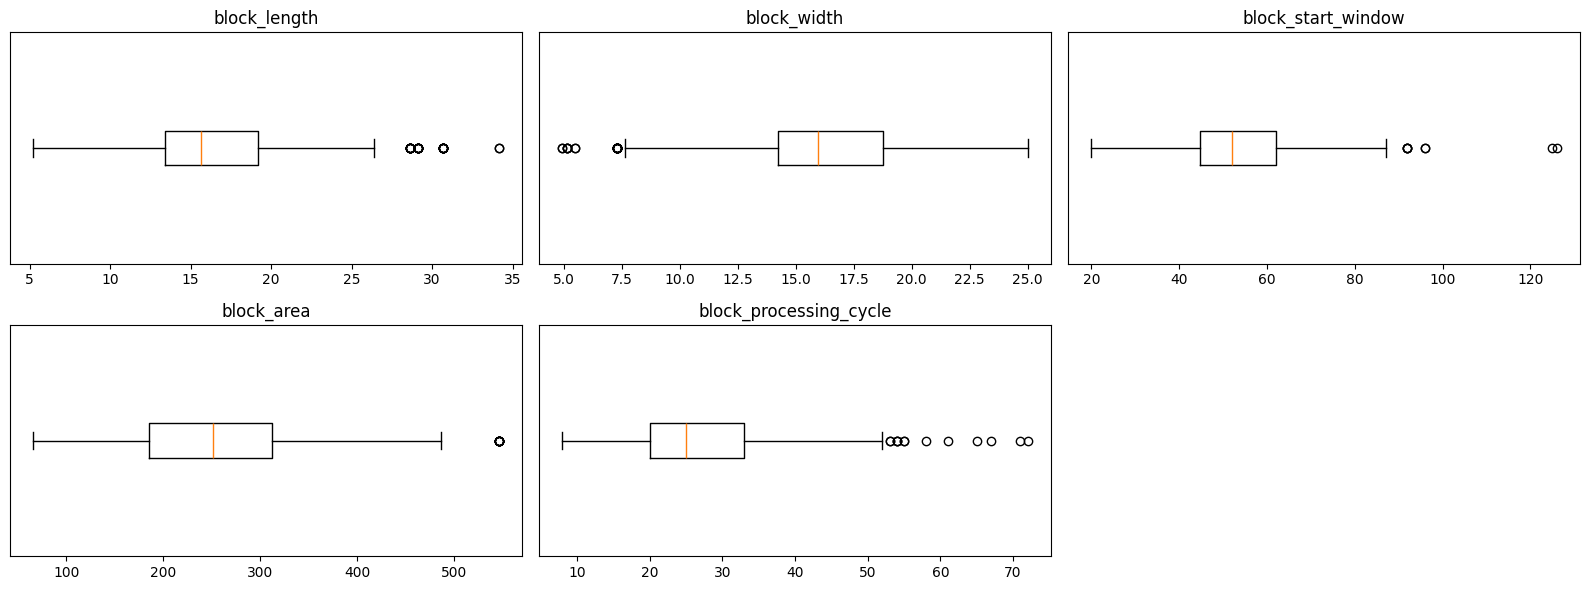

In [14]:
# ============================================================
# IQR 기준 이상치 후보 변수 Boxplot 확인
# ============================================================

# IQR 기준으로 이상치가 확인된 변수만 선택
check_cols = [
    'block_length',
    'block_width',
    'block_start_window',
    'block_area',
    'block_processing_cycle'
]

# 여러 변수의 Boxplot을 한 화면에 배치
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
axes = axes.flatten()

# 변수별 분포와 이상치 위치 확인
for i, col in enumerate(check_cols):
    axes[i].boxplot(analysis[col].dropna(), vert=False)
    axes[i].set_title(col)
    axes[i].set_yticks([])

# 사용하지 않는 빈 그래프 영역 제거
for j in range(len(check_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.1.6 종속변수 및 독립변수 세트 구성

`block_processing_cycle`은 스케줄링 이전에 Block Table에 존재하는 기준 처리기간이다. 최종 예측에는 같은 시점에 알 수 있는 Block 고유 특성만 사용한다.

| 변수 세트 | 구성 | 역할 |
|---|---|---|
| Set A - Block | Block 자체 특성 | **최종 Cycle 예측모델** |
| Set B - Block + Position | Set A + DDQN이 선택한 Position | 사후 정보 추가 효과 진단 |
| Set C - Block + Position + Initial | Set B + `initially_occupied` | 사후 Position 상태 진단 |

Set B/C를 유지하는 이유는 잘못된 최종모델 후보를 만들기 위해서가 아니라, 데이터 생성 순서를 무시하고 결과층 변수를 추가했을 때 성능과 해석이 어떻게 달라지는지 확인하기 위해서다. Position·Initial의 인과효과를 검증하지 않는다.


In [15]:
# ============================================================
# 종속변수 및 Feature Set 정의
# ============================================================

# 예측 대상: 스케줄링 이전 Block Table에 주어진 기준 처리기간
target_col = 'block_processing_cycle'


# ============================================================
# Set A - Block 특성
# ============================================================

# Block 자체의 물리적·일정 특성만 사용
# → 기준 처리기간이 Block 정보만으로 어느 정도 설명되는지 확인
set_a = [
    'block_ship_no',
    'block_type',
    'block_length',
    'block_width',
    'block_weight',
    'block_area',
    'season',
    'block_start_window'
]


# ============================================================
# Set B - Block + Position 특성
# ============================================================

# Set A에 스케줄링을 통해 선택된 Position의 특성을 추가
# → Position 정보가 Cycle 예측 성능에 어떤 영향을 주는지 확인
set_b = set_a + [
    'position_primary_area',
    'position_secondary_area',
    'position_lifting_capacity',
    'position_labor_team',
    'position_block_type',
    'position_attribute',
    'position_area',
    'area_margin_ratio',
    'lifting_load_ratio'
]


# ============================================================
# Set C - Block + Position + Initial 특성
# ============================================================

# Set B에 해당 Position의 스케줄링 시작 시점 초기 점유 상태를 추가
# → 초기 야드 상태 정보까지 포함했을 때의 추가 효과 확인
set_c = set_b + [
    'initially_occupied'
]


# ============================================================
# Feature Set 통합 관리
# ============================================================

# 이후 동일한 모델에 Set A / B / C를 반복 적용하기 위해 Dictionary로 정리
feature_sets = {
    'Set A - Block': set_a,
    'Set B - Block + Position': set_b,
    'Set C - Block + Position + Initial': set_c
}


# ============================================================
# Feature Set 구성 확인
# ============================================================

# Set별 변수 개수와 포함 변수 출력
for name, columns in feature_sets.items():
    print(name, ':', len(columns), 'variables')
    print(columns)
    print()

Set A - Block : 8 variables
['block_ship_no', 'block_type', 'block_length', 'block_width', 'block_weight', 'block_area', 'season', 'block_start_window']

Set B - Block + Position : 17 variables
['block_ship_no', 'block_type', 'block_length', 'block_width', 'block_weight', 'block_area', 'season', 'block_start_window', 'position_primary_area', 'position_secondary_area', 'position_lifting_capacity', 'position_labor_team', 'position_block_type', 'position_attribute', 'position_area', 'area_margin_ratio', 'lifting_load_ratio']

Set C - Block + Position + Initial : 18 variables
['block_ship_no', 'block_type', 'block_length', 'block_width', 'block_weight', 'block_area', 'season', 'block_start_window', 'position_primary_area', 'position_secondary_area', 'position_lifting_capacity', 'position_labor_team', 'position_block_type', 'position_attribute', 'position_area', 'area_margin_ratio', 'lifting_load_ratio', 'initially_occupied']



In [16]:
# ============================================================
# 최종 분석용 데이터 구성
# ============================================================

# Block 식별자 + Set C 전체 변수 + 종속변수만 남김
# → Set A / B / C 비교에 필요한 모든 변수를 포함한 최종 분석 데이터 생성
analysis = analysis[
    ['block_index'] + set_c + [target_col]
].copy()


# ============================================================
# 최종 분석 데이터 확인
# ============================================================

# 최종 데이터 크기와 결측값 여부 확인
print('최종 분석 데이터:', analysis.shape)
print('최종 결측값:', analysis.isna().sum().sum())

# 최종 데이터 구조 확인
analysis.head()

최종 분석 데이터: (872, 20)
최종 결측값: 0


,block_index,block_ship_no,block_type,block_length,block_width,block_weight,block_area,season,block_start_window,position_primary_area,position_secondary_area,position_lifting_capacity,position_labor_team,position_block_type,position_attribute,position_area,area_margin_ratio,lifting_load_ratio,initially_occupied,block_processing_cycle
0,757,H1088,flat,20.000,18.400,211.017143,368.000000,spring,126,block assembly group,No.8 platform,350,HL,flat,general,440.0,0.163636,0.602906,0,72
1,758,H1088,flat,20.000,18.400,211.017143,368.000000,spring,125,platform 1,No.10 platform,280,RH,unrestricted,general,400.0,0.080000,0.753633,0,71
2,823,H1088,flat,6.450,21.691,146.314852,139.906950,spring,79,block assembly group,No.8 platform,350,HL,unrestricted,general,440.0,0.682030,0.418042,0,53
3,822,H1088,flat,20.852,21.691,240.000000,452.300732,spring,79,curved surface,48m,240,MZ,unrestricted,general,462.0,0.020994,1.000000,1,53
4,819,H1088,flat,30.660,9.400,240.000000,288.204000,spring,85,curved surface,45m,240,ZH,flat,general,693.0,0.584121,1.000000,1,61


## 2.2 탐색적 데이터 분석

종속변수 분포와 Block 고유 특성의 관계를 먼저 확인한다. Position 관련 분포는 DDQN이 이미 선택한 배치 결과와 사전 Cycle 사이의 **사후 연관성**으로만 읽는다.

EDA의 목적은 최종 예측변수와 결과 비교용 변수를 구분하고, 다음 모델링 단계에서 데이터 생성 순서를 지키는 것이다.


### 2.2.1 종속변수 분포

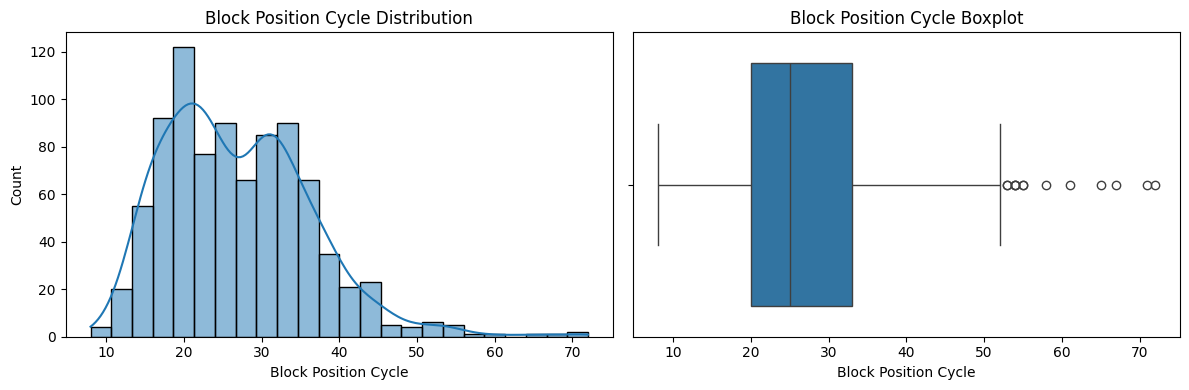

In [17]:
# ============================================================
# 종속변수 Block Position Cycle 분포 확인
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# Histogram과 Boxplot을 한 화면에 배치
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# ------------------------------------------------------------
# 1. Block Position Cycle 전체 분포 확인
# ------------------------------------------------------------

# Histogram + KDE를 이용해 Cycle 값의 분포 형태 확인
sns.histplot(analysis[target_col], kde=True, ax=axes[0])

axes[0].set_title('Block Position Cycle Distribution')
axes[0].set_xlabel('Block Position Cycle')


# ------------------------------------------------------------
# 2. Block Position Cycle 이상치 및 분포 범위 확인
# ------------------------------------------------------------

# Boxplot을 이용해 중앙값, 사분위 범위, 극단값 확인
sns.boxplot(x=analysis[target_col], ax=axes[1])

axes[1].set_title('Block Position Cycle Boxplot')
axes[1].set_xlabel('Block Position Cycle')


plt.tight_layout()
plt.show()

#### 2.2.1.1 종속변수 분포 소결론

`block_processing_cycle`은 대부분 약 15~40일 구간에 집중되어 있으며, 값이 커질수록 빈도가 감소하는 **우측 편향 분포**를 보인다.

IQR 기준으로 50일 이상의 일부 값이 이상치 후보로 탐지되었으나, 장기 Cycle 값들이 일정 범위에 걸쳐 연속적으로 존재하므로 명백한 오류값으로 판단하기 어렵다. 따라서 해당 데이터를 제거하지 않고 유지한다.

다만 장기 Cycle 데이터의 수가 상대적으로 적으므로, 이후 모델링 단계에서 **장기 Cycle 구간의 예측 성능이 저하되는지 별도로 확인할 필요가 있다.**

### 2.2.2 수치형 변수 상관관계

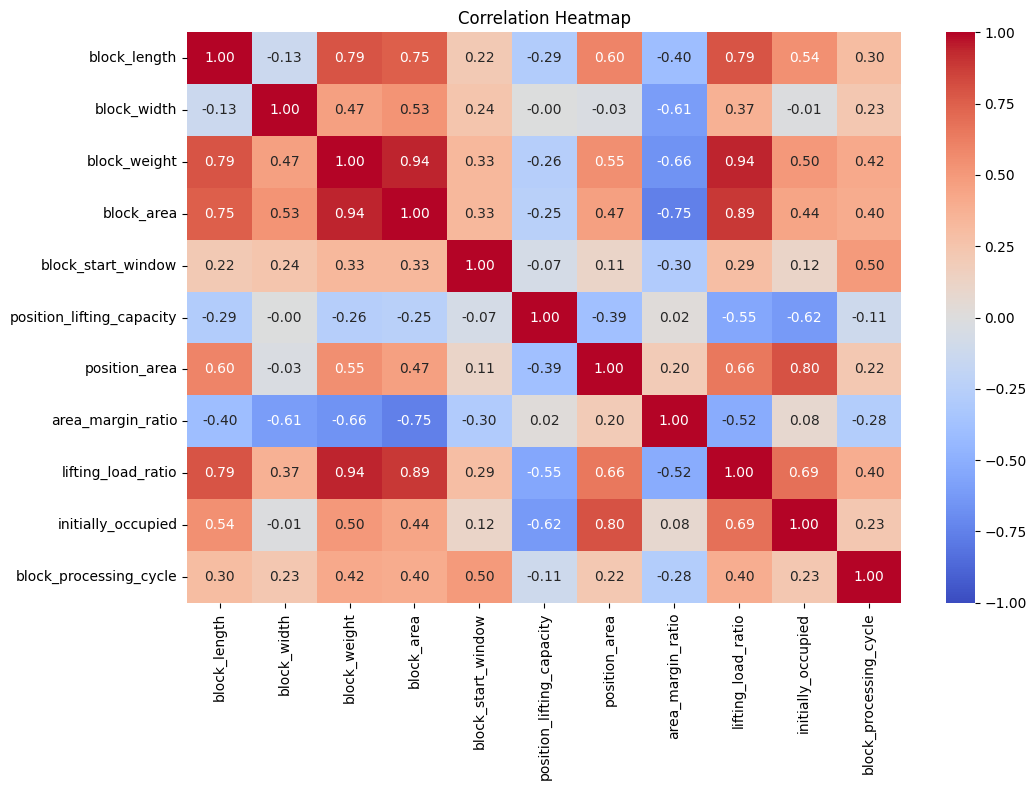

In [18]:
# ============================================================
# 수치형 변수 간 상관관계 확인
# ============================================================

# 상관관계를 확인할 수치형 변수 선택
# → Block 물리량, Position 적합도, 초기 상태 및 Target 포함
numeric_cols = [
    'block_length',
    'block_width',
    'block_weight',
    'block_area',
    'block_start_window',
    'position_lifting_capacity',
    'position_area',
    'area_margin_ratio',
    'lifting_load_ratio',
    'initially_occupied',
    target_col
]


# ============================================================
# 상관계수 계산
# ============================================================

# Pearson 상관계수를 이용해 변수 간 선형관계 확인
corr = analysis[numeric_cols].corr()


# ============================================================
# Correlation Heatmap 시각화
# ============================================================

# 변수 간 상관계수를 한눈에 비교
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

#### 2.2.2.1 수치형 변수 상관관계 소결론

독립변수 간 상관관계를 확인한 결과, 원본 물리량과 파생변수 사이에서 높은 상관관계가 나타났다.

| 변수 조합 | 상관계수 | 해석 및 검토사항 |
|---|---:|---|
| `block_weight` ↔ `block_area` | 0.94 | Block 크기를 나타내는 정보가 중복될 수 있어 다중공선성을 검토한다. |
| `block_weight` ↔ `lifting_load_ratio` | 0.94 | 하중비율의 계산식에 중량이 포함되므로 구조적으로 높은 관계다. |
| `block_area` ↔ `lifting_load_ratio` | 0.89 | 면적과 중량의 관계가 하중비율까지 이어진 것으로 본다. |
| `position_area` ↔ `initially_occupied` | 0.80 | 초기 기록 Position이 상대적으로 큰 Position에 집중된 데이터 구조인지 확인할 필요가 있다. |
| `block_length` ↔ `block_weight` | 0.79 | Block 길이·면적·중량에 크기 정보가 중복 반영될 수 있다. |
| `block_length` ↔ `lifting_load_ratio` | 0.79 | 길이 자체보다 Block 크기와 중량을 통한 간접 관계일 가능성이 높다. |
| `block_area` ↔ `area_margin_ratio` | -0.75 | 두 변수에 Block 면적이 함께 사용되어 발생한 구조적 음의 상관관계다. |

상관관계가 높다는 이유만으로 변수를 즉시 제거하지 않는다. 파생변수의 계산 구조와 실제 의미를 함께 고려하고, 이후 모델 성능 비교를 통해 최종 변수 구성을 판단한다.

### 2.2.3 주요 범주형 변수별 분포

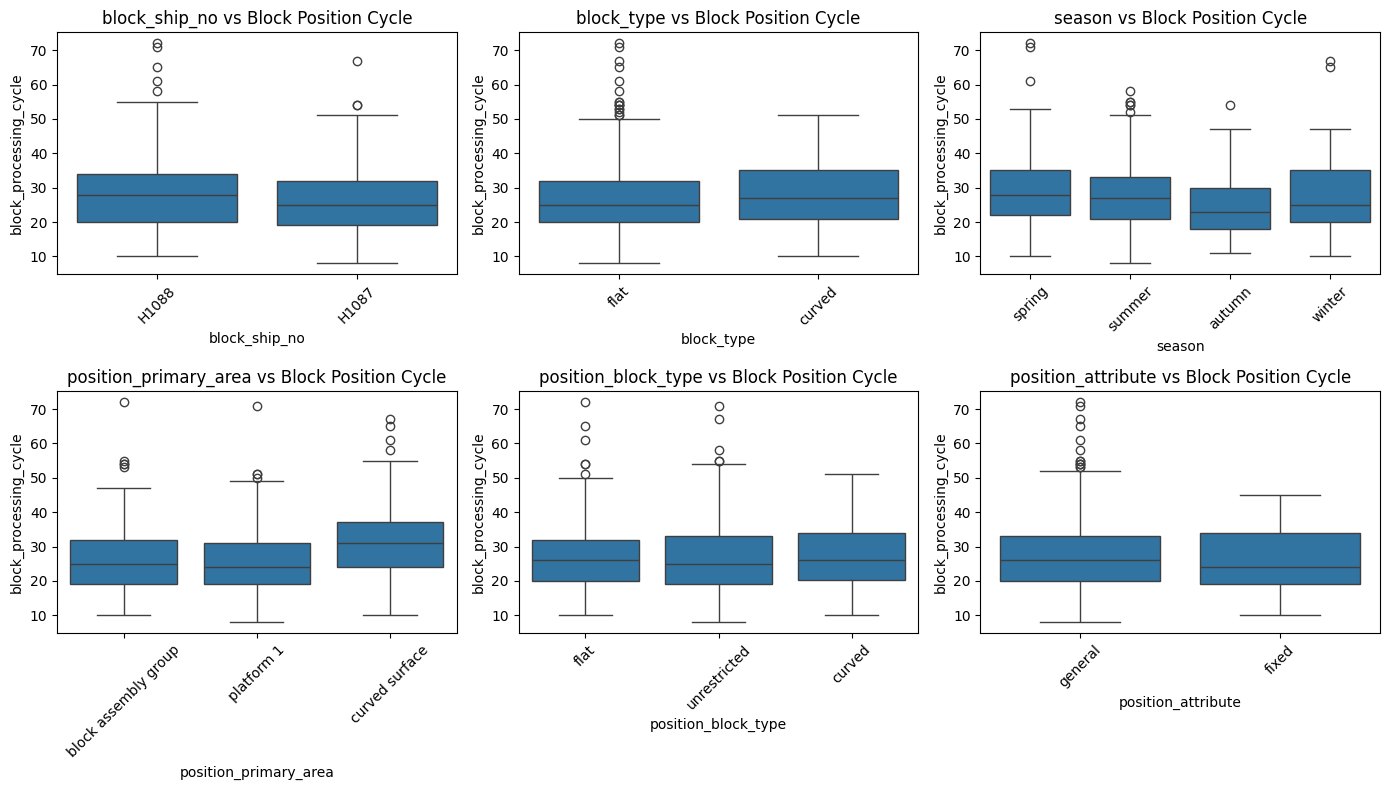

In [19]:
# ============================================================
# 범주형 변수별 Block Position Cycle 분포 비교
# ============================================================

# Block / Position 관련 주요 범주형 변수 선택
category_cols = [
    'block_ship_no',
    'block_type',
    'season',
    'position_primary_area',
    'position_block_type',
    'position_attribute'
]


# 여러 범주형 변수의 Boxplot을 한 화면에 배치
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()


# ============================================================
# 범주별 Cycle 분포 확인
# ============================================================

# 각 범주의 중앙값, 분포 범위 및 이상치 차이를 비교
for i, col in enumerate(category_cols):
    sns.boxplot(data=analysis, x=col, y=target_col, ax=axes[i])

    axes[i].set_title(f'{col} vs Block Position Cycle')
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

#### 2.2.3.1 범주형 변수 분포 소결론

범주형 변수별 `block_processing_cycle` 분포를 비교한 결과, 대부분의 범주에서 분포가 상당 부분 겹쳤다.

| 변수 | 관찰 결과 | 해석상 주의점 |
|---|---|---|
| `block_ship_no` | 두 선박의 중앙값 차이는 크지 않지만 H1088에서 장기 Cycle이 상대적으로 많았다. | 선박별 표본 구성 차이를 함께 고려한다. |
| `block_type` | `curved`의 중앙값이 다소 높지만 `flat`과 분포가 상당히 겹쳤다. | Block Type만으로 Cycle이 뚜렷하게 구분되지는 않는다. |
| `season` | `autumn`은 상대적으로 낮고 `spring`은 높은 경향을 보였다. | 범주별 표본 수와 다른 변수의 영향을 함께 본다. |
| `position_primary_area` | `curved surface`에서 비교적 높은 Cycle 분포가 나타났다. | Position은 DDQN의 선택 결과이므로 원인이 아닌 연관성으로 해석한다. |
| `position_block_type` | `flat`, `unrestricted`, `curved` 사이의 차이가 크지 않았다. | Cycle을 직접 구분하는 효과는 제한적으로 보인다. |
| `position_attribute` | 두 범주의 중앙값과 분포는 겹치지만 `general`에서 장기 Cycle이 더 관찰되었다. | Boxplot만으로 관계를 확정하지 않는다. |

`position_primary_area`와 `season`에서 비교적 눈에 띄는 차이가 관찰되었지만, 최종 판단은 모델링 단계의 예측 기여도와 함께 확인한다.

### 2.2.4 전처리 및 EDA 소결론

- Block 고유 특성과 DDQN 선택 결과를 구분해 변수 세트를 구성했다.
- 최종 Cycle 예측용 Set A에는 스케줄링 이전에 알 수 있는 Block 변수만 포함했다.
- Set B/C는 DDQN Position·Initial을 붙인 탐색적 사후 진단용으로 유지했다.
- 구조적 결측인 `position_block_type`은 `unrestricted`로 변환했고, 이상치는 실제 장기작업·대형 Block일 수 있어 제거하지 않았다.
- EDA에서는 Block의 물리량과 일정 변수에서 비교적 뚜렷한 관계가 관찰됐고, 다수의 Position 범주는 상당 부분 겹쳤다.

다음 3번 노트북에서는 Set A에서 최종 예측모델을 선정하고, Set B/C는 변수 추가 실험으로만 비교한다.


### 2.2.5 분석용 데이터 저장

전처리 데이터와 Set A/B/C 설정을 저장한다. 이 중 **Set A는 최종 예측용**, Set B/C는 탐색적 비교용이라는 역할 구분을 3번 노트북에서도 유지한다.


In [20]:
import json

analysis.to_csv(
    PROCESSED_DIR / 'analysis_DDQN.csv',
    index=False,
    encoding='utf-8-sig'
)

with open(PROCESSED_DIR / 'feature_sets_DDQN.json', 'w', encoding='utf-8') as file:
    json.dump(
        {
            'target': target_col,
            'set_a': set_a,
            'set_b': set_b,
            'set_c': set_c
        },
        file,
        ensure_ascii=False,
        indent=2
    )

print(f"{PROCESSED_DIR / 'analysis_DDQN.csv'} 저장 완료")
print(f"{PROCESSED_DIR / 'feature_sets_DDQN.json'} 저장 완료")

data\processed\analysis_DDQN.csv 저장 완료
data\processed\feature_sets_DDQN.json 저장 완료
